In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('mode.chained_assignment', None)
warnings.simplefilter("ignore", category=RuntimeWarning)

import random
import os
from juno_classes import *

from scipy.integrate import trapz

import matplotlib.colors
from matplotlib.cm import ScalarMappable



def extract_base_exponent_scientific(number):
    exponent = int(np.log10(number))
    base = number / (10 ** exponent)
    return base, exponent

In [2]:
#write something to do averages for raw


def res_plotter(df, x_label, y_label, data_label, x_res, y_res):
    x = df[x_label]
    y = df[y_label]
    data = df[data_label]
    
    xs = np.linspace(x.min(),x.max(), int((x.max()-x.min())/x_res))
    ys = np.linspace(y.min(),y.max(), int((y.max()-y.min())/y_res))


    binned_x_array = np.empty((len(xs)))
    binned_y_array = np.empty((len(ys)))
    binned_data_array = np.empty((len(xs),len(ys)))
    
    x_index = 0
    y_index=0

    for i in xs:
        x_now = i
        average_x = (x_now)
        binned_x_array[x_index] = average_x
        y_index = 0

        for j in ys:
            y_now = j
            average_y = (y_now)
            constrained_array = df.iloc[np.where(   (df[x_label] > (x_now - x_res/2))  &   (df[x_label] < (x_now+x_res/2))   &   (df[y_label] > (y_now-y_res/2))   &      (df[y_label] < (y_now+y_res/2))   )]
        
        
            average_value = np.nanmedian(constrained_array[data_label])
            
            
        
            binned_data_array[x_index,y_index] = average_value 
            binned_y_array[y_index] = average_y
            y_index += 1 
            if y_index == len(ys):
                x_index += 1

  
    
    return binned_x_array, binned_y_array, binned_data_array

In [3]:
def slice_res_plotter(binned_x, binned_y, binned_data,
                      ymin, ymax):
 
    y_mask = (binned_y >= ymin) & (binned_y <= ymax)

    if not np.any(y_mask):
        raise ValueError("No y values lie inside the chosen range.")

    averaged_data = np.nanmedian(binned_data[:, y_mask], axis=1)

    return binned_x, averaged_data


In [4]:
#perp over par

filename = 'data/perp_over_par_df.pkl'
with open(filename, 'rb') as f:
    perp_over_par_mesh = pickle.load(f)

In [5]:
#deltaB_perp


filename = 'data/perp_df.pkl'
with open(filename, 'rb') as f:
    perp_mesh = pickle.load(f)

In [6]:

filename = 'data/norm_res_mesh_df.pkl'
with open(filename, 'rb') as f:
    norm_res_energy_mesh = pickle.load(f)

9.195728444119568e-05
1.9102344056349163


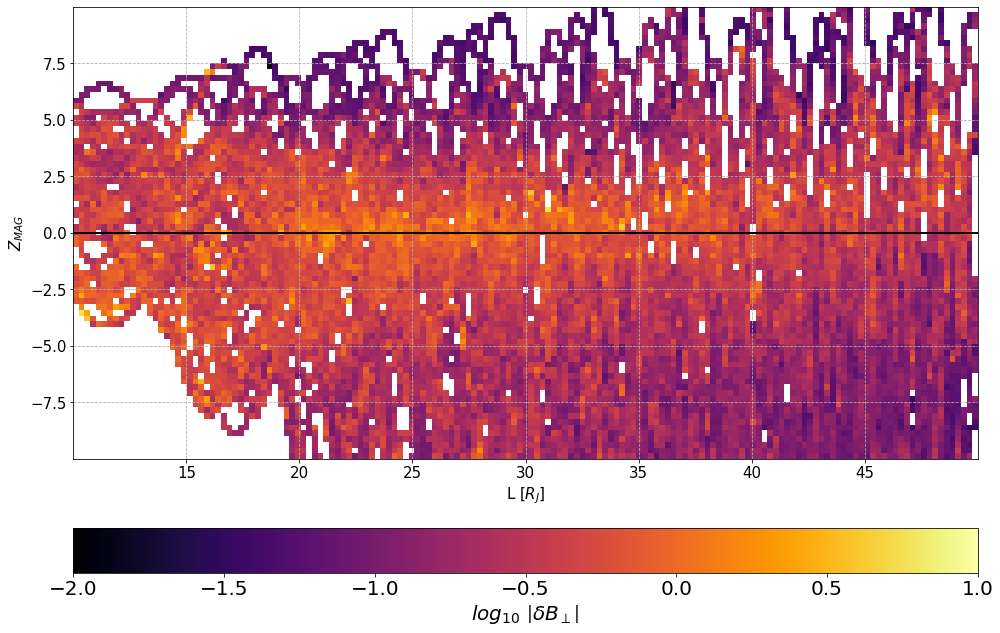

In [7]:
test2 = perp_mesh
x,y = np.meshgrid(test2[0], test2[1])
data = np.log10(test2[2])
fig,ax = plt.subplots(figsize = (14,10),sharex='all',facecolor='white')

c = np.asarray(data)
absc = abs(c)
factor=1
print(np.nanmin(absc))
print(np.nanmax(absc))

norm_1 = plt.Normalize(-2, 1)




cmap= 'inferno'

ax.imshow(c.T, extent=[test2[0].min(), test2[0].max(), test2[1].min(), test2[1].max()], origin='lower', cmap=cmap,norm=norm_1)
ax.axhline(y=0,c='k',linewidth=2)




sm_1 =  ScalarMappable(norm=norm_1, cmap=cmap)
sm_1.set_array([])
cbar_1 = fig.colorbar(sm_1, ax=ax,orientation='horizontal',pad=0.1,)
cbar_1.set_label(r'$log_{10}$ $\left|{\delta}B_{\perp}\right|$', size = (20))
cbar_1.ax.tick_params(labelsize=20)


ax.set_ylabel(r'$Z_{MAG}$',fontsize=15)
ax.set_xlabel(r'L $[R_J]$',fontsize=15)
ax.set_facecolor('white')
ax.tick_params(axis='both', labelsize=15)

plt.grid(True, which='both', linestyle='--', alpha=1)

plt.tight_layout()
plt.show()



0.028122149702955714
4.103260070109162


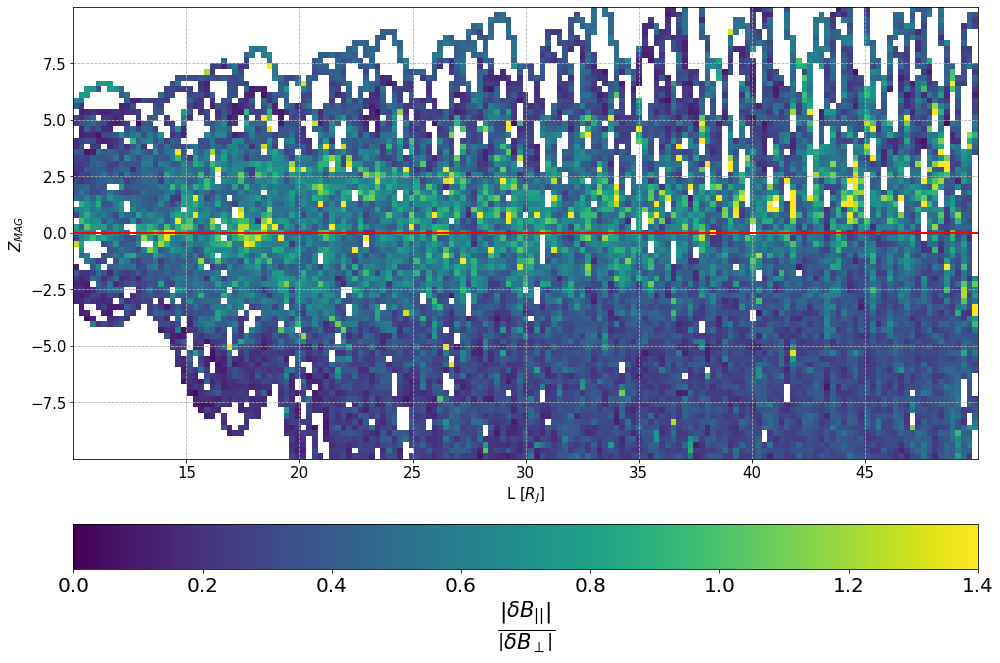

In [8]:
test2 = perp_over_par_mesh
x,y = np.meshgrid(test2[0], test2[1])
data = 1/(test2[2])
fig,ax = plt.subplots(figsize = (14,10),sharex='all',facecolor='white')

c = np.asarray(data)
absc = abs(c)
factor=1
print(np.nanmin(absc))
print(np.nanmax(absc))


norm_1 = plt.Normalize(0, 1.4)



cmap= 'viridis'

ax.imshow(c.T, extent=[test2[0].min(), test2[0].max(), test2[1].min(), test2[1].max()], origin='lower', cmap=cmap,norm=norm_1)
ax.axhline(y=0,c='red',linewidth=2)




sm_1 =  ScalarMappable(norm=norm_1, cmap=cmap)
sm_1.set_array([])
cbar_1 = fig.colorbar(sm_1, ax=ax,orientation='horizontal',pad=0.1,)
cbar_1.set_label(r'$\frac{\left|{\delta}B_{||}\right|}{\left|{\delta}B_{\perp}\right|}$', size = (30))
cbar_1.ax.tick_params(labelsize=20)




ax.set_ylabel(r'$Z_{MAG}$',fontsize=15)
ax.set_xlabel(r'L $[R_J]$',fontsize=15)
ax.set_facecolor('white')
ax.tick_params(axis='both', labelsize=15)

plt.grid(True, which='both', linestyle='--', alpha=1)

plt.tight_layout()
plt.show()



In [9]:
import seaborn as sns
from matplotlib.colors import ListedColormap

-0.09233646619532682
0.9856423102155084


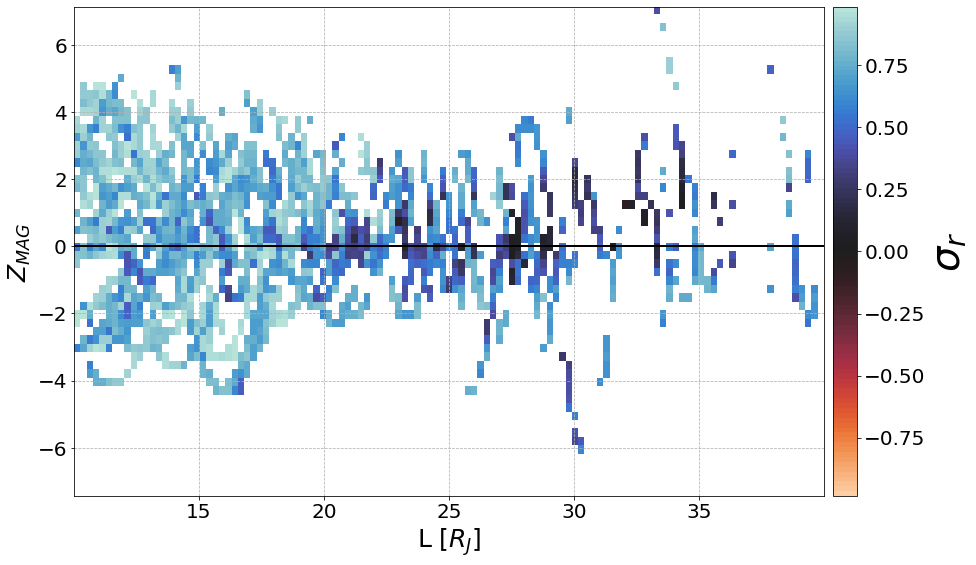

In [10]:
test4 = norm_res_energy_mesh
x,y = np.meshgrid(test4[0], test4[1])
data = (test4[2])
fig,ax = plt.subplots(figsize = (16,9),sharex='all',facecolor='white')

c = np.asarray(data)
absc = abs(c)
factor=1

print(np.nanmin(c))
print(np.nanmax(c))

norm_4 =plt.Normalize(-max(absc[np.where((absc)>0)])/factor, max(absc[np.where((absc) > 0)])/factor)


cmap = 'coolwarm_r'
my_cmap = ListedColormap(sns.color_palette("icefire_r",n_colors=100).as_hex())
cmap = my_cmap


ax.imshow(c.T, extent=[test4[0].min(), test4[0].max(), test4[1].min(), test4[1].max()], origin='lower', cmap=cmap,norm=norm_4,aspect='auto')
ax.axhline(y=0,c='k',linewidth=2)



sm_1 =  ScalarMappable(norm=norm_4, cmap=cmap)
sm_1.set_array([])
cbar_1 = fig.colorbar(sm_1, ax=ax,orientation='vertical',pad=0.01,)
cbar_1.set_label(r'$\sigma_r$', size = (40))
cbar_1.ax.tick_params(labelsize=20)




ax.set_ylabel(r'$Z_{MAG}$',fontsize=25)
ax.set_xlabel(r'L $[R_J]$',fontsize=25)
ax.set_facecolor('white')
ax.tick_params(axis='both', labelsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.75)



plt.show()



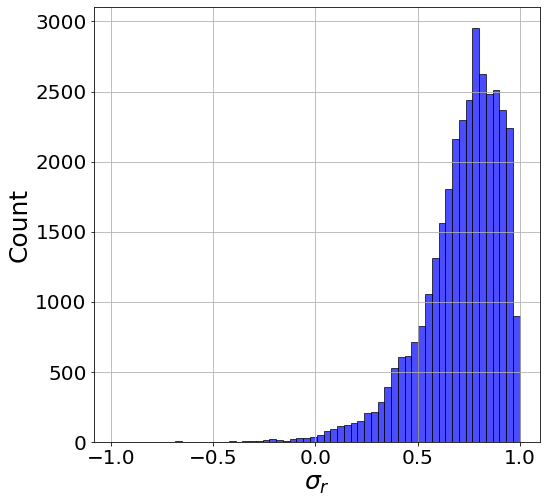

29621
63.182031483298495


In [11]:
#make histogram of mean norm res energy values
filename = 'data/residual_energy_data.pkl'
picklefile = open(filename,'rb')
combined_fits_dfs = pickle.load(picklefile)

number_of_bins = 60
plt.figure(figsize=(8, 8),facecolor= 'white')
plt.hist(combined_fits_dfs['MEAN_norm_residual_energy'], bins=number_of_bins, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('$\sigma_r$',fontsize = 25)
plt.ylabel('Count', fontsize = 25)
plt.grid()
label_size_set2 = 20
plt.tick_params(axis='both', labelsize=label_size_set2)

plt.show()


point5_to_1 = len((np.where( (combined_fits_dfs['MEAN_norm_residual_energy'] > 0.5)  &   (combined_fits_dfs['MEAN_norm_residual_energy'] < 1.)  ))[0])

print(point5_to_1)


print(point5_to_1/len(combined_fits_dfs['MEAN_norm_residual_energy'])*100)